In [51]:
# 🎬 Scenario: You received a JPG from a drone camera. Before processing, understand its
#  dimensions, color space, and pixel type.


import cv2
import numpy as np
import matplotlib.pyplot as plt

# from google.colab.patches import cv2_imshow ------ for colab bcs in jupyter matplot works

In [52]:
img = cv2.imread('flower.jpeg')

Shape : (187, 270, 3)
Dtype : uint8
Size  : 151470


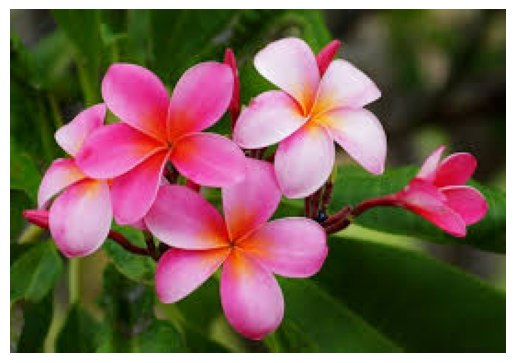

In [53]:
if img is None:
    print("Error: Could not load image. Please ensure 'drone_photo.jpg' exists and the path is correct.")
else:
    print('Shape :', img.shape)     # (height, width, channels)
    print('Dtype :', img.dtype)     # uint8  →  0-255 per channel
    print('Size  :', img.size)      # total number of pixels

    # cv2.cvtColor() converts the image from BGR to RGB color space.
    # plt.imshow() displays the image, plt.axis("off") removes axes, and plt.show() renders the image output.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

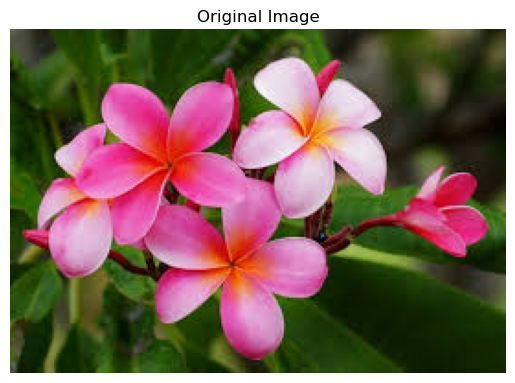

In [54]:
import cv2

img = cv2.imread('flower.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

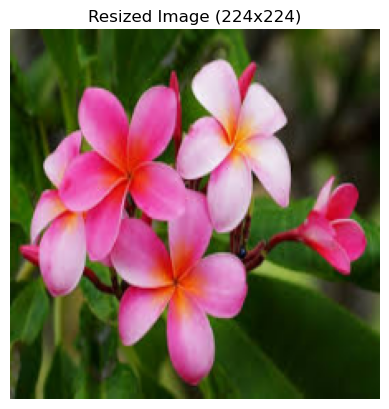

In [55]:
# ── Resize ───────────────────────────────────────────────
# 224 and 224 mai resize kar dega yeh
resized = cv2.resize(img, (224, 224))# fixed WxH

resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
plt.imshow(resized_rgb)
plt.title("Resized Image (224x224)")
plt.axis("off")
plt.show()

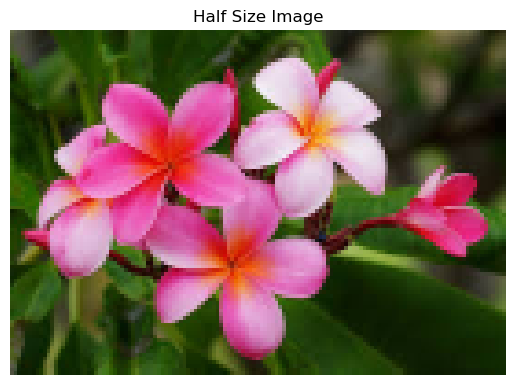

In [56]:
# half kar dega image ko
# fx = 0.5 means ki width reduced to 50% and fy = 0.5 means ki height reduced to 50%             
half    = cv2.resize(img, None, fx=0.5, fy=0.5)  # 50% scale
half_rgb = cv2.cvtColor(half, cv2.COLOR_BGR2RGB)

plt.imshow(half_rgb)
plt.title("Half Size Image")
plt.axis("off")
plt.show()

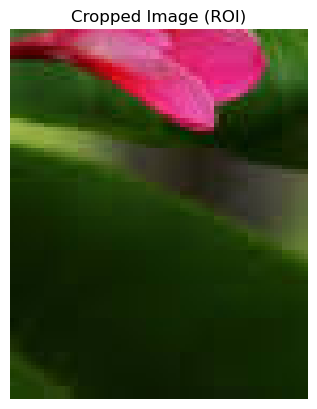

In [57]:
# ── Crop (NumPy slicing) ─────────────────────────────────
# 100:400 - vertical crop and 200:600 - horizontal crop
roi = img[100:400, 200:600]   # [y1:y2, x1:x2]
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

plt.imshow(roi_rgb)
plt.title("Cropped Image (ROI)")
plt.axis("off")
plt.show()

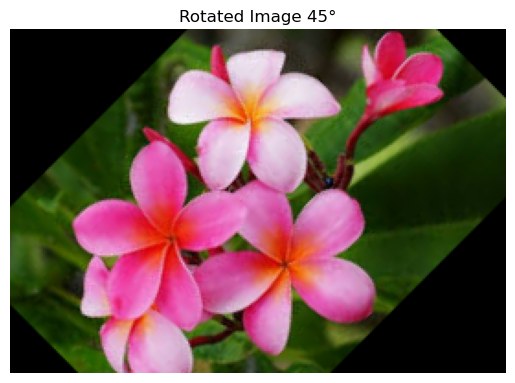

In [58]:
# ── Rotate 45° around centre ─────────────────────────────

# h - height and w = width
h, w = img.shape[:2]

# (w//2, h//2) -- center of image , 45 ------rotation angle , 1.0 ----scaling factor
M   = cv2.getRotationMatrix2D((w//2, h//2), 45, 1.0)

# warpAffine() applies the transformation matrix M to the image.
rot = cv2.warpAffine(img, M, (w, h))

rot_rgb = cv2.cvtColor(rot, cv2.COLOR_BGR2RGB)

plt.imshow(rot_rgb)
plt.title("Rotated Image 45°")
plt.axis("off")
plt.show()

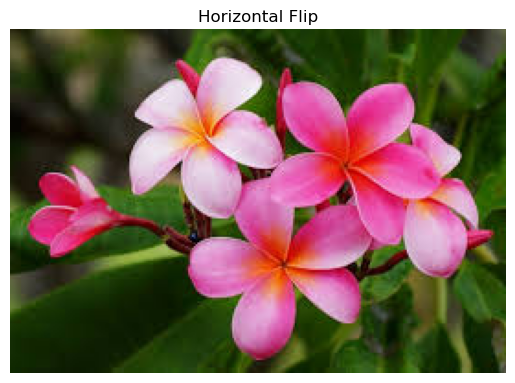

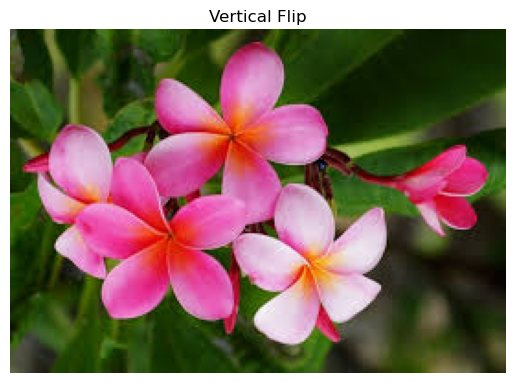

In [59]:
# ── Flip ─────────────────────────────────────────────────
flip_h = cv2.flip(img,  1)   # horizontal
flip_h_rgb = cv2.cvtColor(flip_h, cv2.COLOR_BGR2RGB)

plt.imshow(flip_h_rgb)
plt.title("Horizontal Flip")
plt.axis("off")
plt.show()


flip_v = cv2.flip(img,  0)   # vertical
flip_v_rgb = cv2.cvtColor(flip_v, cv2.COLOR_BGR2RGB)

plt.imshow(flip_v_rgb)
plt.title("Vertical Flip")
plt.axis("off")
plt.show()

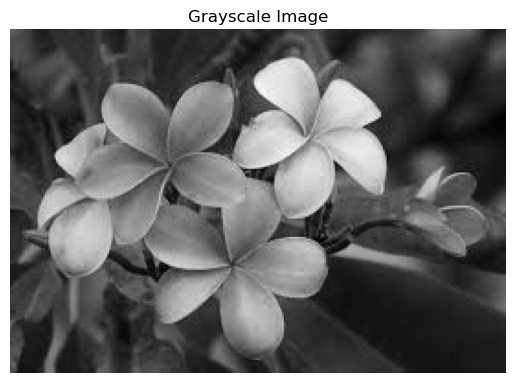

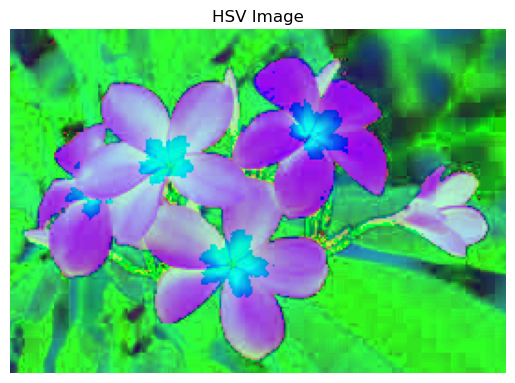

In [60]:
# ── Colour conversions ───────────────────────────────────

# grayscale mai convert
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

#  H         - Hue (color)            
#  S         - Saturation (intensity) 
#  V         - Value (brightness)     
hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
plt.imshow(hsv)
plt.title("HSV Image")
plt.axis("off")
plt.show()

In [61]:
# 🎬 Scenario:
# We have a scanned document (like a report or form).
# Scanned documents usually contain noise, shadows, and uneven lighting.
# Before performing OCR (Optical Character Recognition),
# we clean the image so that text becomes clearer.

In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [63]:
img = cv2.imread('report.jpeg')
# img = cv2.imread('image.png')
# img = cv2.imread('image1.png')

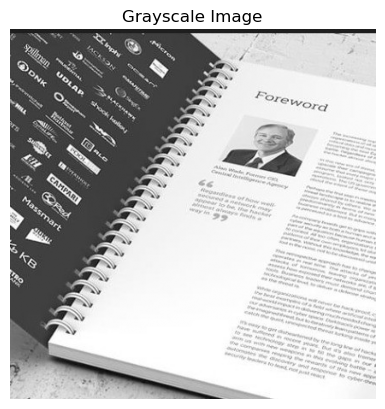

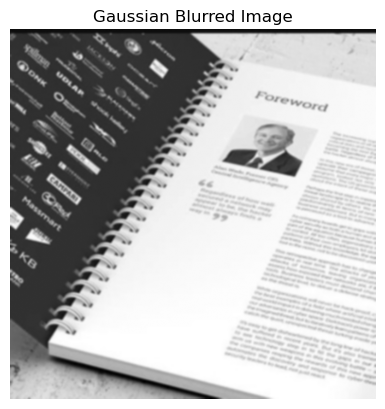

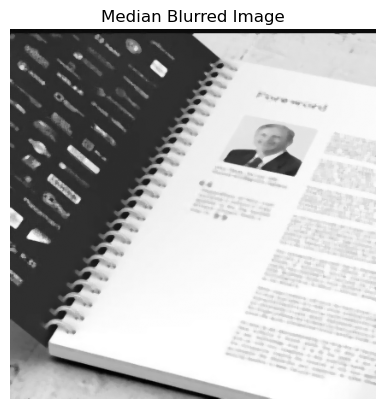

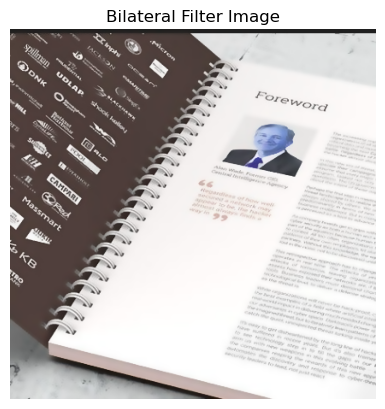

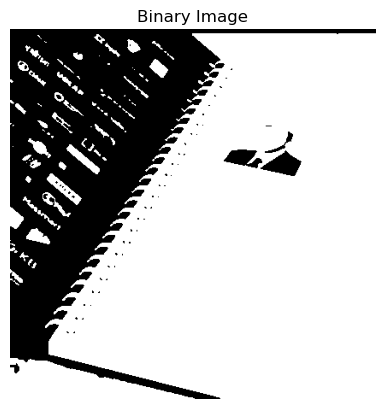

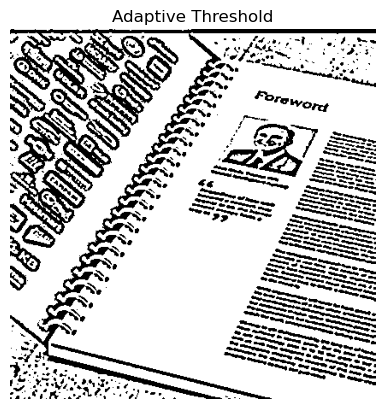

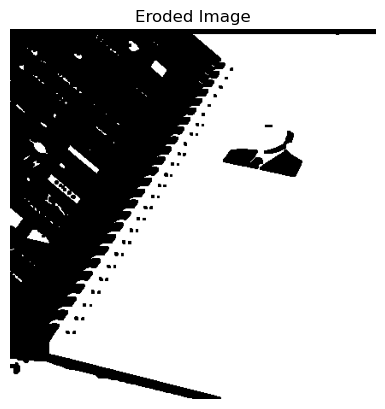

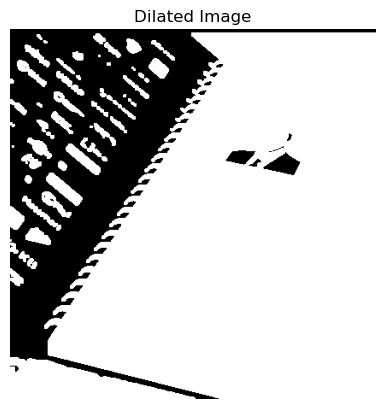

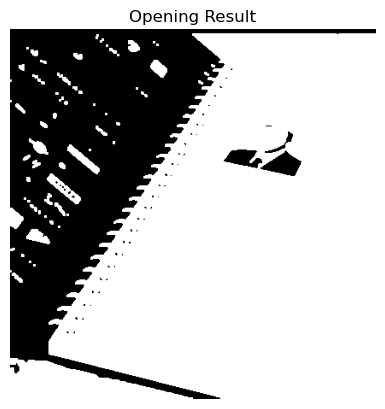

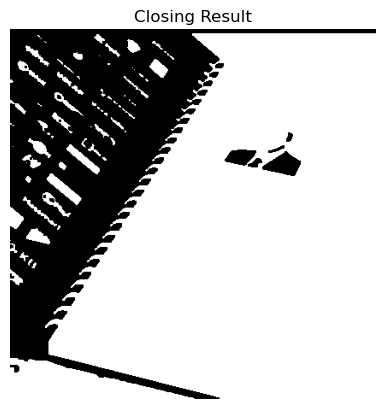

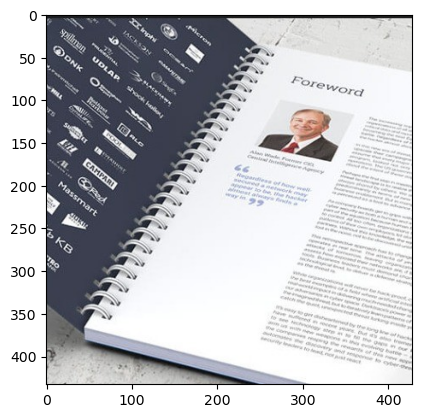

In [64]:
if img is None:
    print("Error: Could not load image. Please ensure 'document.jpg' exists and the path is correct.")

else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis("off")
    plt.show()

    
    # This line uses Gaussian Blur to smooth the image and reduce noise. It is a common preprocessing step in computer vision using OpenCV.
    # cv2.GaussianBlur(image, kernel_size, sigma(standard deviation))
    # takes avg
    # Blur → edges become soft
    blur_g = cv2.GaussianBlur(gray, (5, 5), 0)
    plt.imshow(blur_g, cmap='gray')
    plt.title("Gaussian Blurred Image")
    plt.axis("off")
    plt.show()


    # This line applies Median Blur to the grayscale image to remove noise while preserving edges
    # takes the median after sorting and replace with center
    # Blur → edges become soft   
    blur_m = cv2.medianBlur(gray, 5)
    plt.imshow(blur_m, cmap='gray')
    plt.title("Median Blurred Image")
    plt.axis("off")
    plt.show()


    # This line applies a Bilateral Filter to the image. It is an advanced smoothing technique in OpenCV that reduces noise while preserving edges.
    # Blur → noise removed , edges preserved
    # cv2.bilateralFilter(image, diameter, sigmaColor, sigmaSpace)
    # This controls how much color difference is allowed during smoothing---sigmacolor
    # This controls how far pixels influence each other based on distance.-----sigmaspace
    blur_b = cv2.bilateralFilter(img, 9, 75, 75)
    plt.imshow(blur_b, cmap='gray')
    plt.title("Bilateral Filter Image")
    plt.axis("off")
    plt.show()


    kernel = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])

    #  line applies the kernel (filter) you defined earlier to the grayscale image to produce a sharpened image using OpenCV.
    sharp = cv2.filter2D(gray, -1, kernel)

    # Thresholding converts a grayscale image into a binary image (black and white).
    # cv2.threshold(src, threshold_value, max_value, threshold_type)
    #  _ ignore the first returned value
    _, thresh = cv2.threshold(
        blur_g,
        127,
        255,
        cv2.THRESH_BINARY
    )
    plt.imshow(thresh, cmap='gray')
    plt.title("Binary Image")
    plt.axis("off")
    plt.show()


    adap_thresh = cv2.adaptiveThreshold(

        blur_g,                        # input image
        255,                           # max value (white)
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,# threshold method
        cv2.THRESH_BINARY,             # binary output
        11,                            # neighborhood block size
        2                              # constant subtracted
    )
    plt.imshow(adap_thresh, cmap='gray')
    plt.title("Adaptive Threshold")
    plt.axis("off")
    plt.show()


    kernel2 = np.ones((3, 3), np.uint8)


    # Erosion removes pixels from the boundaries of white objects.
    # cv2.erode(src, kernel, iterations)
    eroded = cv2.erode(
        thresh,
        kernel2,
        iterations=1
    )
    plt.imshow(eroded, cmap='gray')
    plt.title("Eroded Image")
    plt.axis("off")
    plt.show()



    # Dilation expands the white regions in a binary image.
    # cv2.dilate(src, kernel, iterations)
    dilated = cv2.dilate(
        thresh,
        kernel2,
        iterations=1
    )
    plt.imshow(dilated, cmap='gray')
    plt.title("Dilated Image")
    plt.axis("off")
    plt.show()
    

    # The two operations are Opening and Closing, which help clean and refine binary images.
    # cv2.morphologyEx() is a function used to perform advanced morphological transformations like: opening , closing , gradient , top hat ,black hat
    opened = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel2
    )
    plt.imshow(opened, cmap='gray')
    plt.title("Opening Result")
    plt.axis("off")
    plt.show()

    closed = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel2
    )
    plt.imshow(closed, cmap='gray')
    plt.title("Closing Result")
    plt.axis("off")
    plt.show()

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
    plt.imshow(img_rgb)


In [65]:
# Scenario: Smart Dashcam Lane Detection
# Imagine you’re building a smart dashcam system for cars that helps drivers stay in their lanes. The dashcam captures frames of
#  the road, and your algorithm processes them step by step:
# - Step 1 – Capture the road scene
# The dashcam takes a snapshot (road.jpg). This is the raw input, just like a driver’s eye view.
# - Step 2 – Focus on essentials
# Convert the image to grayscale. Colors aren’t important for lane detection; what matters are contrasts and shapes.
# - Step 3 – Smooth out distractions
# Apply a Gaussian blur to reduce noise. Think of it as filtering out small pebbles or shadows that could confuse the system.
# - Step 4 – Spot the lane boundaries
# Use Canny edge detection to highlight sharp changes in intensity—these are likely lane markings.
# - Step 5 – Define the driver’s view
# Create a region of interest (ROI) shaped like a trapezoid, covering the part of the road where lanes usually appear. This prevents
#  the system from wasting effort on irrelevant areas like the sky or nearby buildings.
# - Step 6 – Overlay results for feedback
# Combine the detected edges with the original frame. The driver (or tester) now sees lane boundaries highlighted directly on the
# road image.



In [66]:
# 🎯 Teaching Angle
# This scenario shows how computer vision can be applied to real-world problems. Instead of just running code, learners can imagine
# themselves designing a lane-assist feature for autonomous vehicles. Each step connects to a practical need: clarity, focus, safety.

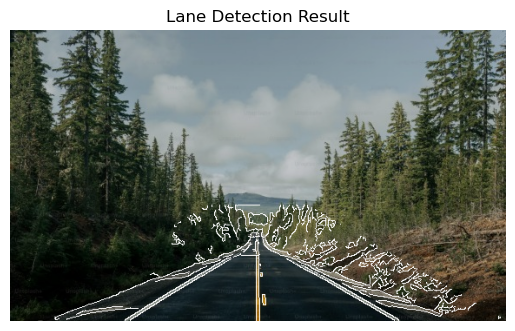

In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load image
frame = cv2.imread('road.jpeg')

if frame is None:
    print("Error: Could not load image")
    exit()

# Step 2: Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Step 3: Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5,5), 0)

# Step 4: Canny Edge Detection
edges = cv2.Canny(blurred, 50, 150)

# Step 5: Region of Interest
h, w = edges.shape
mask = np.zeros_like(edges)

pts = np.array([[0,h],[w,h],[int(w*0.6),int(h*0.6)],[int(w*0.4),int(h*0.6)]], np.int32)

cv2.fillPoly(mask, [pts], 255)

roi = cv2.bitwise_and(edges, mask)

# Step 6: Overlay edges on original image
edges_col = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)

result = cv2.addWeighted(frame, 0.8, edges_col, 1.0, 0)

# Convert BGR → RGB for display
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Step 7: Display
plt.imshow(result_rgb)
plt.title("Lane Detection Result")
plt.axis("off")
plt.show()